In [1]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import glob
import random
import netCDF4 as nc

In [2]:
# Function to open an npz file
def open_npz_file(npz_path):
    """Open an npz file and return the chip and metadata"""
    try:
        archive = np.load(npz_path, allow_pickle=True)
        chip = archive['chip']
        data = archive['data'].item()
        return chip, data
    except Exception as e:
        print(f"Error opening {npz_path}: {str(e)}")
        return None, None

In [3]:
# Function to find all npz files in a directory
def find_npz_files(directory_path):
    """Find all .npz files in a directory"""
    npz_pattern = os.path.join(directory_path, "*.npz")
    npz_files = glob.glob(npz_pattern)
    npz_files.sort()  
    return npz_files

In [6]:
# 1. LOAD COORDINATE LOOKUP DATA (Same as your script)
LATLONDATA = "/home/al8425b-hpc/NASA/cropTest/testData/ABI_EAST_GEO_TOPO_LOMSK.nc"
f_coords = nc.Dataset(LATLONDATA)
abiLong = np.array(f_coords['Longitude'])
abiLat = np.array(f_coords['Latitude'])
abiLong[abiLong < 0] += 360

In [ ]:
# LATLONDATA = "/home/al8425b-hpc/NASA/cropTest/testData/ABI_EAST_GEO_TOPO_LOMSK.nc"

# BOUND_SIZE = 1600
# LENGTH = 10848

# f = nc.Dataset(LATLONDATA)
# abiLong = np.array(f['Longitude'])
# abiLat = np.array(f['Latitude'])

# abiLongB = abiLong[BOUND_SIZE:LENGTH-BOUND_SIZE, BOUND_SIZE:LENGTH-BOUND_SIZE]
# abiLatB = abiLat[BOUND_SIZE:LENGTH-BOUND_SIZE, BOUND_SIZE:LENGTH-BOUND_SIZE]
# abiLongB[abiLongB == -999] = 10
# abiLatB[abiLatB == -999] = 10
# abiLongB[abiLongB < 0] += 360

In [4]:
def visualize_chips(lon_chip, lat_chip, abi_image, data):
    # 1. Create the 'canvas'
    plt.figure(figsize=(10, 8))
    # 2. Define the geographic boundaries of the chip
    # extent = [left, right, bottom, top]
    img_extent = [lon_chip.min(), lon_chip.max(), lat_chip.min(), lat_chip.max()]
    print(img_extent)
    # 3. Draw the ABI image
    # cmap='gray' makes it look like a standard satellite image
    # origin='upper' ensures the top of the array is the top of the plot
    # plt.imshow(abi_image, extent=img_extent, cmap='gray', origin='upper')
    plt.imshow(abi_image, extent=img_extent, cmap='gray') 
    # plt.imshow(abi_image) 
    # 4. Add a colorbar so you know what the values mean
    plt.colorbar(label='Radiance')
    # 5. Draw the transect on top!
    # data['Longitude'] and data['Latitude'] are your 91 points
    # plt.pcolormesh(lon_chip, lat_chip, abi_image, cmap='gray', shading='auto')
    plt.plot(data['Longitude'], data['Latitude'], color='red', linewidth=2, label='CloudSat Track')
    # 6. Add labels and a title
    plt.title("ABI Chip with CloudSat Transect Overlay")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    # 7. Show the plot
    plt.show()

In [16]:
def visualize_transect(x_center, y_center, data):
    # 1. Create the 'canvas'
    plt.figure(figsize=(10, 8))
    # 2. Define the geographic boundaries of the chip
    # extent = [left, right, bottom, top]
    # img_extent = [x_center-]
    # 3. Draw the ABI image
    # cmap='gray' makes it look like a standard satellite image
    # origin='upper' ensures the top of the array is the top of the plot
    # plt.imshow(abi_image, extent=img_extent, cmap='gray', origin='upper')
    # plt.imshow(abi_image, extent=img_extent, cmap='gray') 
    # plt.imshow(abi_image) 
    # 4. Add a colorbar so you know what the values mean
    # plt.colorbar(label='Radiance')
    # 5. Draw the transect on top!
    # data['Longitude'] and data['Latitude'] are your 91 points
    # plt.pcolormesh(lon_chip, lat_chip, abi_image, cmap='gray', shading='auto')
    plt.plot(data['Longitude'], data['Latitude'], color='red', linewidth=2, label='CloudSat Track')
    # 6. Add labels and a title
    plt.title("CloudSat Transect Overlay")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    # 7. Show the plot
    plt.show()

/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/2020-001-72861_1600-9026-13670.npz
[339.70306, 349.43295, 40.984364, 43.769524]


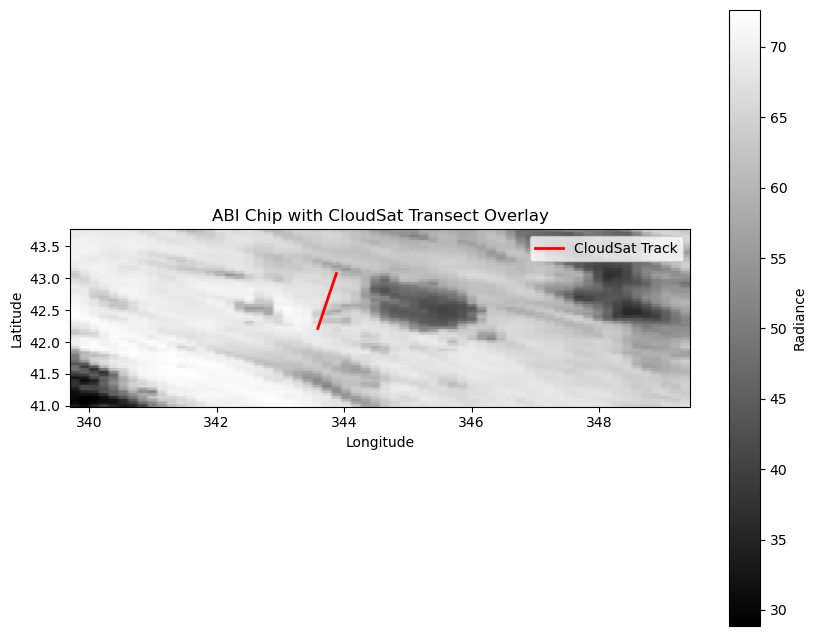

lat length 91
long length 91
Transect Latitude Range: 42.21265411376953 to 43.07488250732422
Chip Latitude Range: 40.9843635559082 to 43.76952362060547
Transect Longitude Range: 343.5879669189453 to 343.87879371643066
Chip Longitude Range: 339.70306396484375 to 349.4329528808594

/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/2020-001-72861_1600-9029-13625.npz
[339.7967, 349.60773, 40.992916, 43.78755]


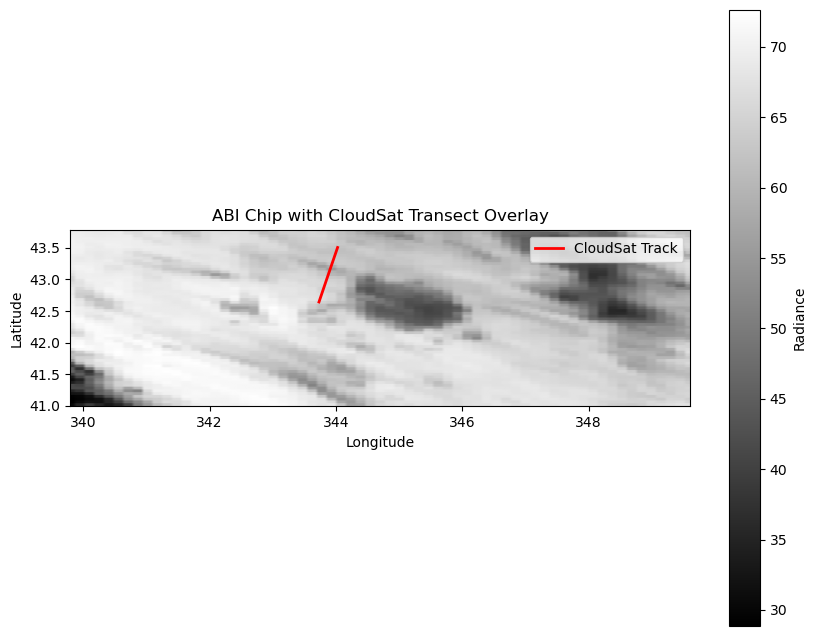

lat length 91
long length 91
Transect Latitude Range: 42.64384460449219 to 43.505767822265625
Chip Latitude Range: 40.992916107177734 to 43.78755187988281
Transect Longitude Range: 343.7325859069824 to 344.0266447067261
Chip Longitude Range: 339.79669189453125 to 349.60772705078125

/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/2020-001-72861_1600-9033-13580.npz
[339.9221, 349.8451, 41.00439, 43.812122]


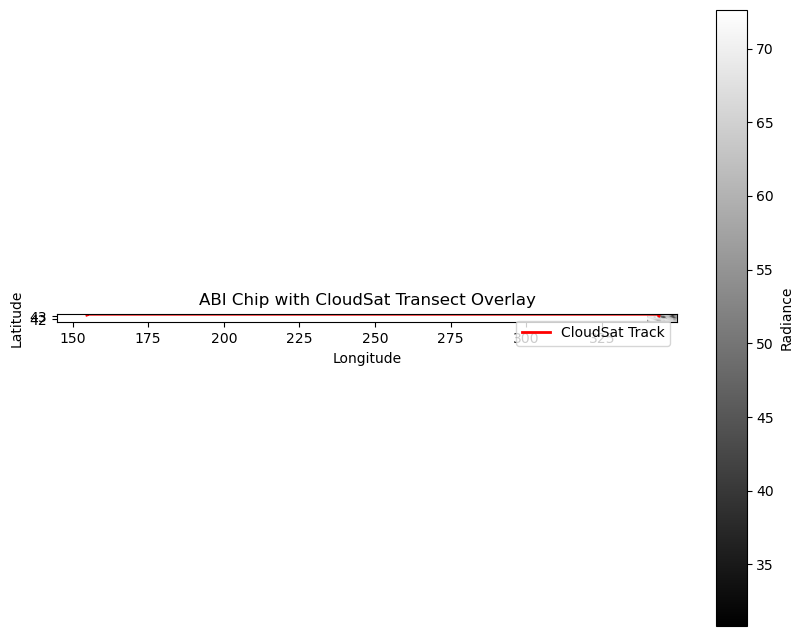

lat length 91
long length 91
Transect Latitude Range: 43.07488250732422 to 43.6543083190918
Chip Latitude Range: 41.004390716552734 to 43.8121223449707
Transect Longitude Range: 154.6080780029297 to 344.0762996673584
Chip Longitude Range: 339.9220886230469 to 349.8450927734375

/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/2020-001-72861_1602-9024-13715.npz
[339.5903, 349.20593, 40.945873, 43.716057]


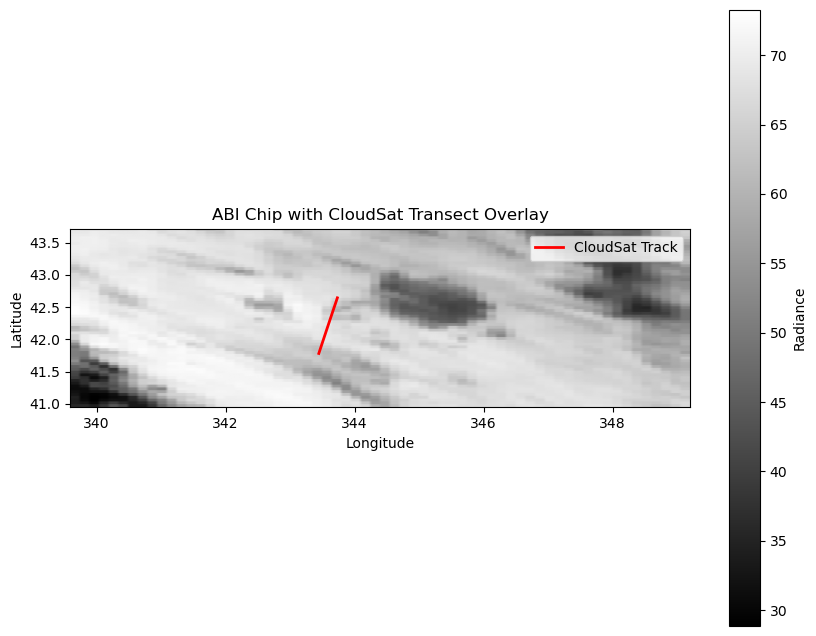

lat length 91
long length 91
Transect Latitude Range: 41.781314849853516 to 42.64384460449219
Chip Latitude Range: 40.94587326049805 to 43.71605682373047
Transect Longitude Range: 343.44489097595215 to 343.7325859069824
Chip Longitude Range: 339.5903015136719 to 349.2059326171875

/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/2020-001-72861_1631-9045-13760.npz
[339.52216, 348.85114, 40.534386, 43.251606]


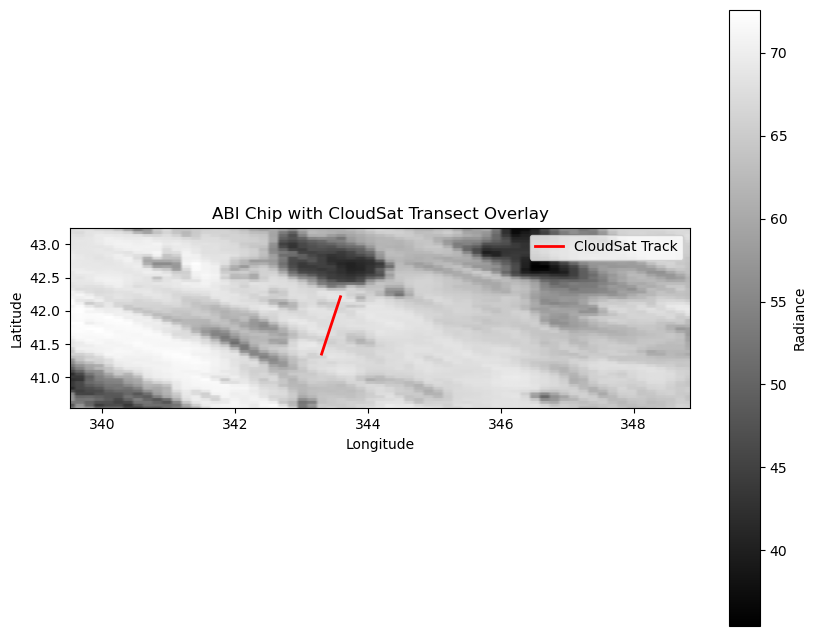

lat length 91
long length 91
Transect Latitude Range: 41.349830627441406 to 42.21265411376953
Chip Latitude Range: 40.534385681152344 to 43.25160598754883
Transect Longitude Range: 343.303316116333 to 343.5879669189453
Chip Longitude Range: 339.52215576171875 to 348.85113525390625

/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/2020-001-72861_1660-9066-13805.npz
[339.46667, 348.53137, 40.127506, 42.794262]


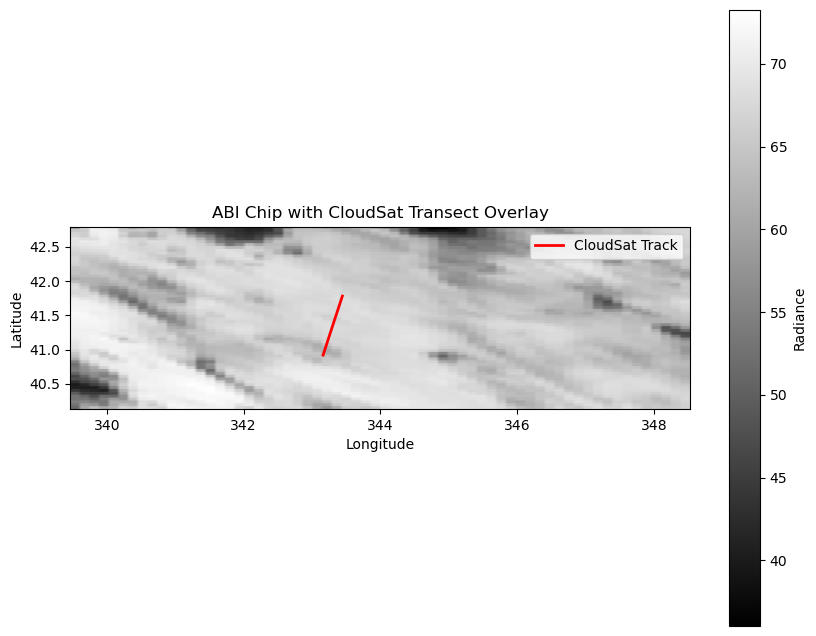

lat length 91
long length 91
Transect Latitude Range: 40.91820526123047 to 41.781314849853516
Chip Latitude Range: 40.127506256103516 to 42.79426193237305
Transect Longitude Range: 343.16320037841797 to 343.44489097595215
Chip Longitude Range: 339.4666748046875 to 348.5313720703125

/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/2020-001-72861_1690-9087-13850.npz
[339.39822, 348.20627, 39.708584, 42.32682]


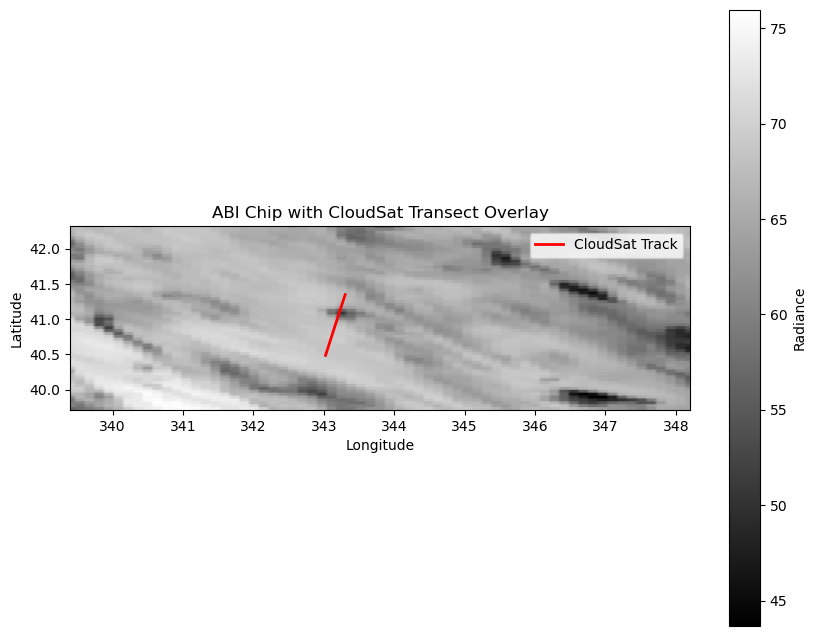

lat length 91
long length 91
Transect Latitude Range: 40.4864387512207 to 41.349830627441406
Chip Latitude Range: 39.70858383178711 to 42.326820373535156
Transect Longitude Range: 343.02450942993164 to 343.303316116333
Chip Longitude Range: 339.3982238769531 to 348.2062683105469

/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/2020-001-72861_1720-9108-13895.npz
[339.34286, 347.9146, 39.294422, 41.866554]


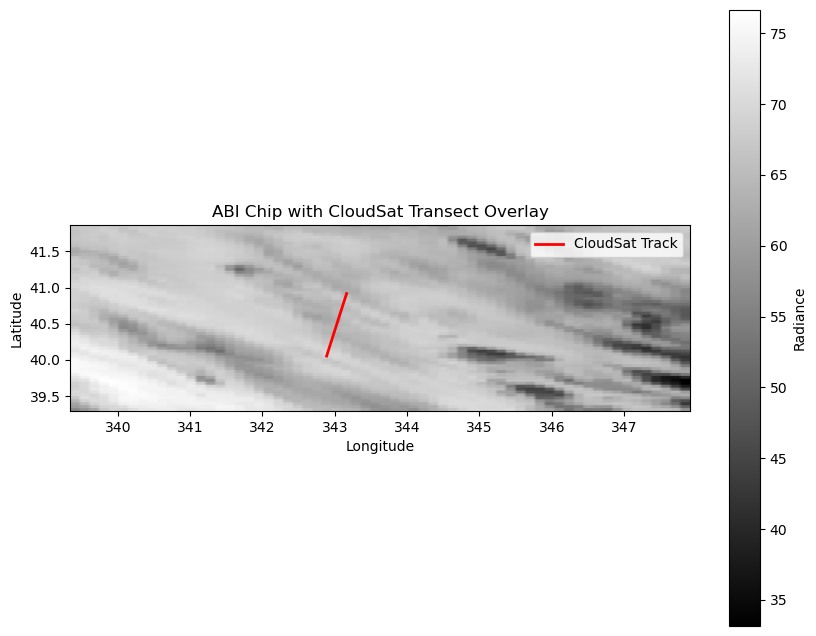

lat length 91
long length 91
Transect Latitude Range: 40.05453872680664 to 40.91820526123047
Chip Latitude Range: 39.2944221496582 to 41.866554260253906
Transect Longitude Range: 342.88719940185547 to 343.16320037841797
Chip Longitude Range: 339.3428649902344 to 347.91461181640625

/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/2020-001-72861_1750-9128-13940.npz
[339.26706, 347.6074, 38.880997, 41.408848]


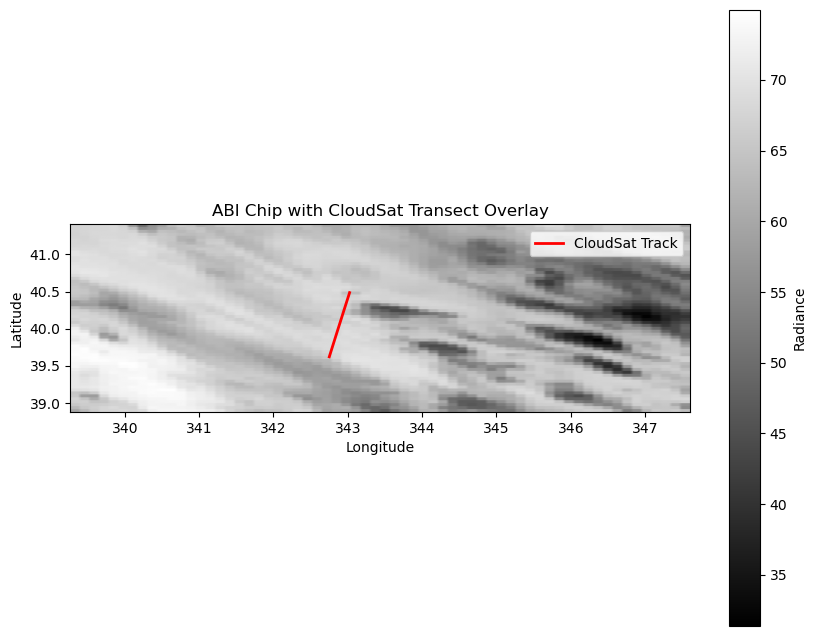

lat length 91
long length 91
Transect Latitude Range: 39.62250518798828 to 40.4864387512207
Chip Latitude Range: 38.88099670410156 to 41.40884780883789
Transect Longitude Range: 342.75123023986816 to 343.02450942993164
Chip Longitude Range: 339.2670593261719 to 347.6073913574219

/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/2020-001-72861_1781-9149-13985.npz
[339.21252, 347.34012, 38.459736, 40.945198]


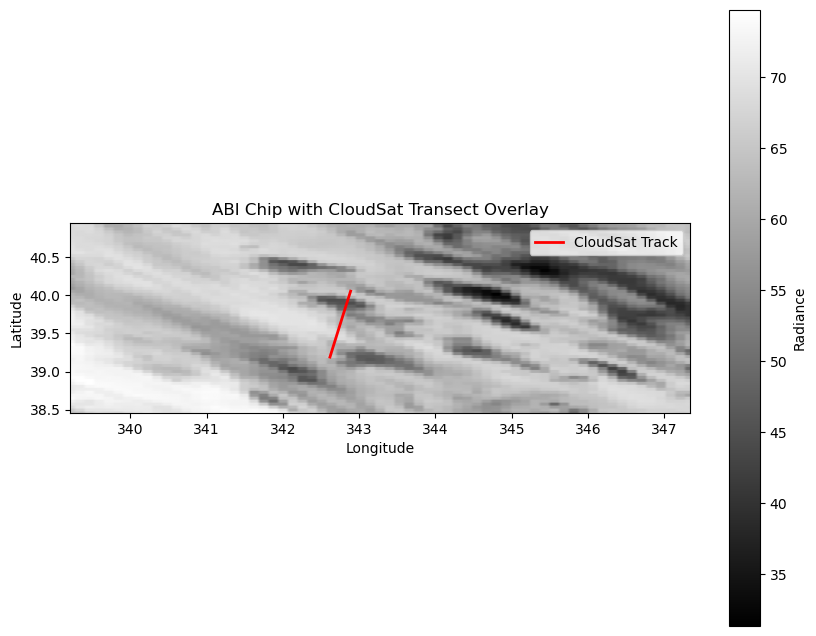

lat length 91
long length 91
Transect Latitude Range: 39.190338134765625 to 40.05453872680664
Chip Latitude Range: 38.45973587036133 to 40.94519805908203
Transect Longitude Range: 342.61656761169434 to 342.88719940185547
Chip Longitude Range: 339.2125244140625 to 347.3401184082031

10


In [ ]:
output_directory = '/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/'
files = find_npz_files(output_directory)

half = 64

count =0

for file in files:
    chip, data = open_npz_file(file)
    coords = file.split('/')[-1].split('_')[-1].split('-')
    # print(file.split('/')[-1].split('_')[-1].split('-'))
    y_center = int(coords[0])
    x_center = int(coords[1])
    print(file)
    
    
    lat_chip = abiLat[y_center-half : y_center+half, x_center-half : x_center+half]
    lon_chip = abiLong[y_center-half : y_center+half, x_center-half : x_center+half]
    # lon_chip[lon_chip < 0] += 360
    
    abi_image = chip[2, :, :, 12]
    
    # if data["Longitude"][0] < 250 and data["Longitude"][0] > 150:
    count +=1
    
    #     # print(y_center, x_center)
    visualize_chips(lon_chip, lat_chip, abi_image, data)
    # visualize_transect(x_center, y_center, data)
    
    print('lat length', len(data['Latitude']))
    print('long length', len(data['Longitude']))
    
    print(f"Transect Latitude Range: {data['Latitude'].min()} to {data['Latitude'].max()}")
    print(f"Chip Latitude Range: {lat_chip.min()} to {lat_chip.max()}")

    print(f"Transect Longitude Range: {data['Longitude'].min()} to {data['Longitude'].max()}")
    print(f"Chip Longitude Range: {lon_chip.min()} to {lon_chip.max()}")
    print()

        
        
    if count == 10:
        break

print(count)

# this is very messed up
   
    


In [ ]:

output_directory = '/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/2020-001-72864_5616-5264-180.npz'

chip, data = open_npz_file(output_directory)

# print(chip.shape)
print(data.keys())

# these are both 91 1d arrays
print(data['Latitude'])
print(data['Longitude'])


The file name of each npz file is the key that allows us to access the correct lat and long cords in the ABI_EAST_GEO_TOPO_LOMSK.nc file 

2020-001-72864_1600-4173-13765.npz 
the middle part of this 1600 4173 represents coords[0] and coords[1]

* 1600: The center row index (Y) in the full ABI grid.
* 4173: The center column index (X) in the full ABI grid.

In [ ]:
# 1. LOAD COORDINATE LOOKUP DATA (Same as your script)
LATLONDATA = "/home/al8425b-hpc/NASA/cropTest/testData/ABI_EAST_GEO_TOPO_LOMSK.nc"
f_coords = nc.Dataset(LATLONDATA)
abiLong = np.array(f_coords['Longitude'])
abiLat = np.array(f_coords['Latitude'])
abiLong[abiLong < 0] += 360

In [ ]:
print(abiLong.shape)
print(abiLat.shape)

In [ ]:
y_center = 5616
x_center = 5264
# x_center = 1600 
# y_center = 4173

In [ ]:
half = 64
lat_chip = abiLat[y_center-half : y_center+half, x_center-half : x_center+half]
lon_chip = abiLong[y_center-half : y_center+half, x_center-half : x_center+half]

In [ ]:
print(lat_chip.shape)
print(lon_chip.shape)

In [ ]:
print(lat_chip)
print(lon_chip)

so the 1600 and 4173 are the center indexes  of the chip, and the .nc file contains the coords for every pixle in the array, so we get those indicies from    
 the file name, and grab the lat and long for every pixle from the .nc file

In [ ]:
# going to use band 13 for now
# chip shape is (5, 128, 128, 16)
abi_image = chip[2, :, :, 12]
# grabbing the second time step and the 13th band

In [ ]:
# 1. Create the 'canvas'
plt.figure(figsize=(10, 8))
# 2. Define the geographic boundaries of the chip
# extent = [left, right, bottom, top]
img_extent = [lon_chip.min(), lon_chip.max(), lat_chip.min(), lat_chip.max()]
# 3. Draw the ABI image
# cmap='gray' makes it look like a standard satellite image
# origin='upper' ensures the top of the array is the top of the plot
# plt.imshow(abi_image, extent=img_extent, cmap='gray', origin='upper')
plt.imshow(abi_image, extent=img_extent, cmap='gray') 
# plt.imshow(abi_image) 
# 4. Add a colorbar so you know what the values mean
plt.colorbar(label='Radiance')
# 5. Draw the transect on top!
# data['Longitude'] and data['Latitude'] are your 91 points
# plt.plot(data['Longitude'], data['Latitude'], color='red', linewidth=2, label='CloudSat Track')
# 6. Add labels and a title
plt.title("ABI Chip with CloudSat Transect Overlay")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
# 7. Show the plot
plt.show()

In [ ]:
# 1. Create the 'canvas'
plt.figure(figsize=(10, 8))
# 2. Define the geographic boundaries of the chip
# extent = [left, right, bottom, top]
img_extent = [lon_chip.min(), lon_chip.max(), lat_chip.min(), lat_chip.max()]
# 3. Draw the ABI image
# cmap='gray' makes it look like a standard satellite image
# origin='upper' ensures the top of the array is the top of the plot
# plt.imshow(abi_image, extent=img_extent, cmap='gray', origin='upper')
plt.imshow(abi_image, extent=img_extent, cmap='gray') 
# plt.imshow(abi_image) 
# 4. Add a colorbar so you know what the values mean
plt.colorbar(label='Radiance')
# 5. Draw the transect on top!
# data['Longitude'] and data['Latitude'] are your 91 points
# plt.pcolormesh(lon_chip, lat_chip, abi_image, cmap='gray', shading='auto')
plt.plot(data['Longitude'], data['Latitude'], color='red', linewidth=2, label='CloudSat Track')
# 6. Add labels and a title
plt.title("ABI Chip with CloudSat Transect Overlay")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
# 7. Show the plot
plt.show()

In [ ]:
print(f"Transect Latitude Range: {data['Latitude'].min()} to {data['Latitude'].max()}")
print(f"Chip Latitude Range: {lat_chip.min()} to {lat_chip.max()}")

print(f"Transect Longitude Range: {data['Longitude'].min()} to {data['Longitude'].max()}")
print(f"Chip Longitude Range: {lon_chip.min()} to {lon_chip.max()}")